download cifar10 dataset

In [ ]:
import numpy as np
from keras.src.metrics.metrics_utils import confusion_matrix
from numpy import ndarray
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import keras
from tensorflow.keras.utils import plot_model
import os
import json
from sklearn.metrics import ConfusionMatrixDisplay

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

assumptions about the dataset

In [18]:
num_of_classes = 10

evaluate input data

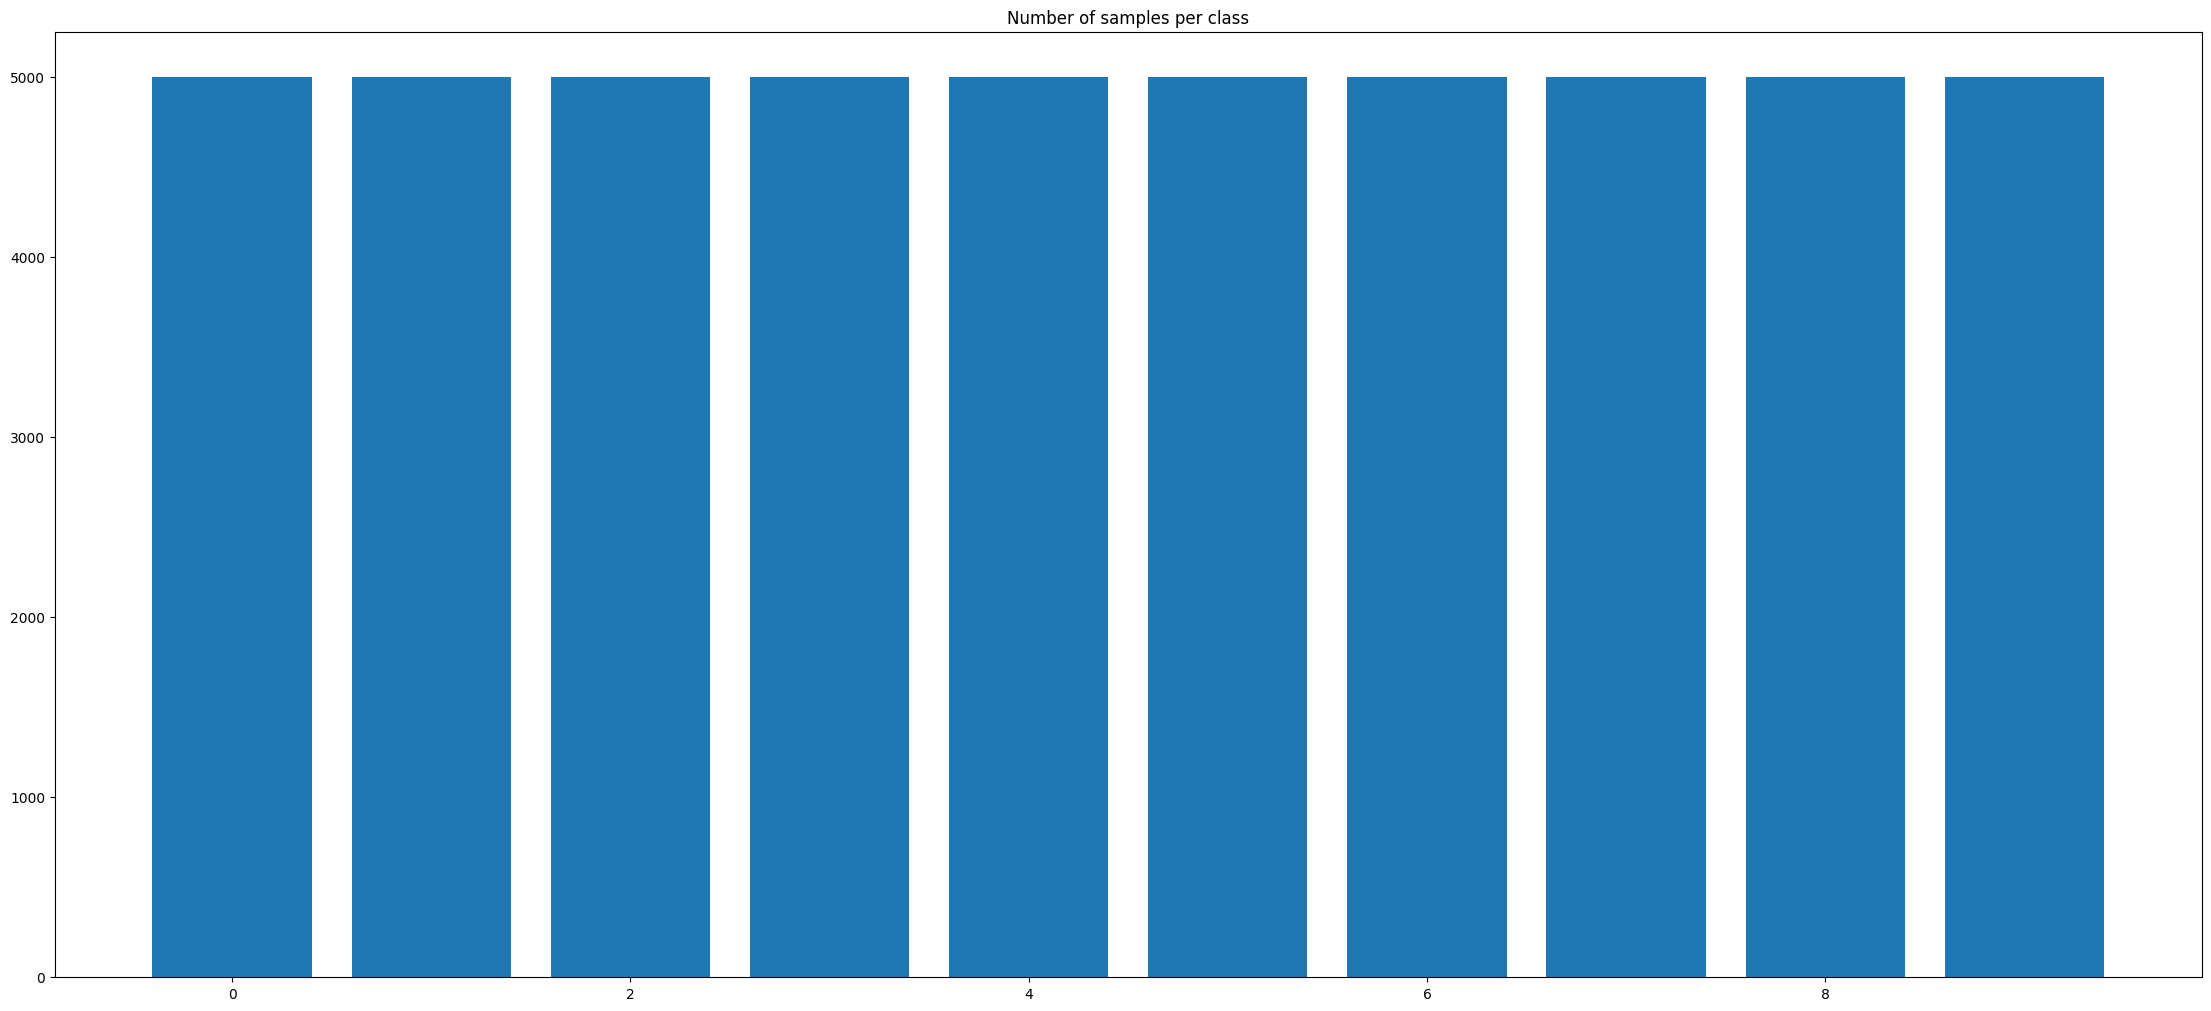

In [19]:
count_of_samples = {}

assert 0 == len(y_train[y_train == None])
assert 0 == len(y_test[y_test == None])

assert False == np.isnan(x_train).any()
assert False == np.isnan(x_test).any()

for label in range(0,num_of_classes):
    count_of_samples[label] = len(y_train[y_train == label])


fig, axes = plt.subplots(1, 1, figsize=(22, 10), constrained_layout=True)

axes.bar(count_of_samples.keys(), count_of_samples.values())
axes.set_title("Number of samples per class")

plt.show()

normalize features data

In [20]:
def normalize_image_data(data_set: ndarray) -> np.ndarray:
    normalized = data_set.copy()
    print(f"shape before : {normalized.shape}")
    normalized.reshape(data_set.shape[0], data_set.shape[1], data_set.shape[2], 3)
    print(f"shape after : {normalized.shape}")
    return normalized / 255

x_train = normalize_image_data(x_train)
x_test = normalize_image_data(x_test)

print(x_train[1])
print(x_test[1])

shape before : (50000, 32, 32, 3)
shape after : (50000, 32, 32, 3)
shape before : (10000, 32, 32, 3)
shape after : (10000, 32, 32, 3)
[[[0.60392157 0.69411765 0.73333333]
  [0.49411765 0.5372549  0.53333333]
  [0.41176471 0.40784314 0.37254902]
  ...
  [0.35686275 0.37254902 0.27843137]
  [0.34117647 0.35294118 0.27843137]
  [0.30980392 0.31764706 0.2745098 ]]

 [[0.54901961 0.62745098 0.6627451 ]
  [0.56862745 0.6        0.60392157]
  [0.49019608 0.49019608 0.4627451 ]
  ...
  [0.37647059 0.38823529 0.30588235]
  [0.30196078 0.31372549 0.24313725]
  [0.27843137 0.28627451 0.23921569]]

 [[0.54901961 0.60784314 0.64313725]
  [0.54509804 0.57254902 0.58431373]
  [0.45098039 0.45098039 0.43921569]
  ...
  [0.30980392 0.32156863 0.25098039]
  [0.26666667 0.2745098  0.21568627]
  [0.2627451  0.27058824 0.21568627]]

 ...

 [[0.68627451 0.65490196 0.65098039]
  [0.61176471 0.60392157 0.62745098]
  [0.60392157 0.62745098 0.66666667]
  ...
  [0.16470588 0.13333333 0.14117647]
  [0.23921569 0.

format label data

In [21]:
def format_label_data(data_set: ndarray) -> ndarray:
    formatted = data_set.copy().reshape(-1)
    print(f"shape before : {data_set.shape}")
    formatted = tf.one_hot(formatted.astype(np.int32), depth=10).numpy()
    print(f"shape after : {formatted.shape}")
    return formatted

y_train = format_label_data(y_train)
y_test = format_label_data(y_test)

assert 10 == y_train.shape[1]
assert 10 == y_test.shape[1]

shape before : (50000, 1)
shape after : (50000, 10)
shape before : (10000, 1)
shape after : (10000, 10)


build convolutional network model

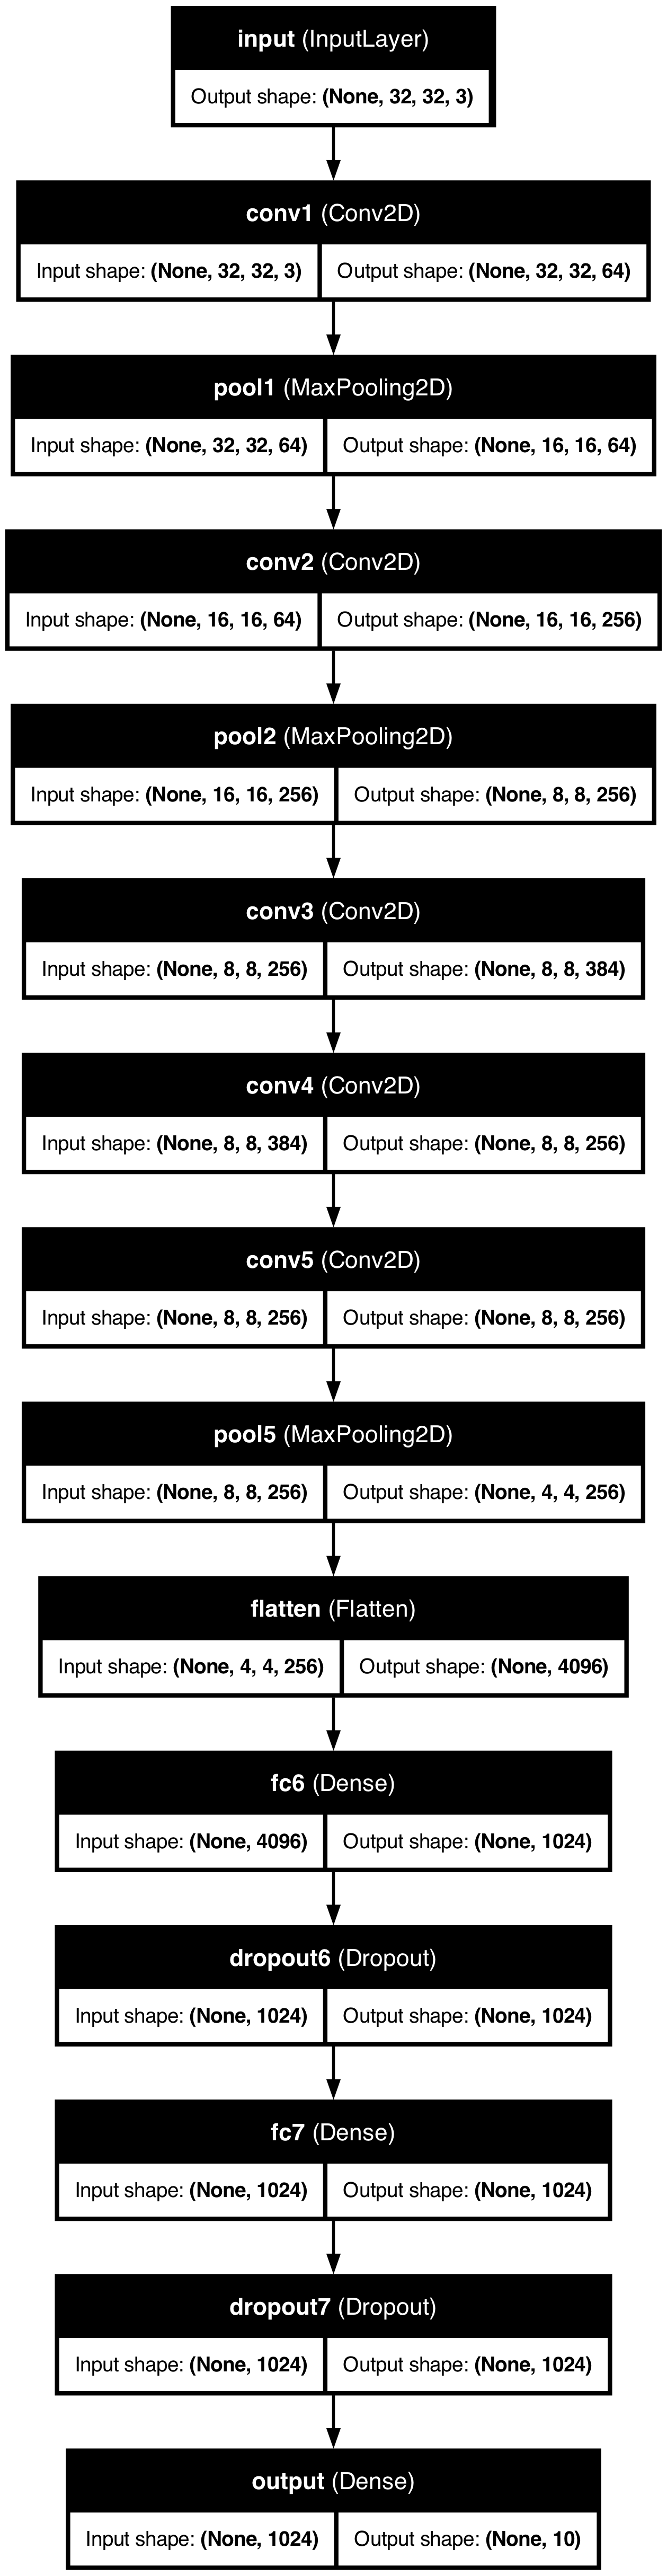

In [22]:
inputs = keras.Input(shape=(32, 32, 3), name="input")

# alex net like network
x = keras.layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu", name="conv1")(inputs)
x = keras.layers.MaxPooling2D(2, name="pool1")(x)

x = keras.layers.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu", name="conv2")(x)
x = keras.layers.MaxPooling2D(2, name="pool2")(x)

x = keras.layers.Conv2D(filters=384, kernel_size=3, padding="same", activation="relu", name="conv3")(x)
x = keras.layers.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu", name="conv4")(x)
x = keras.layers.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu", name="conv5")(x)
x = keras.layers.MaxPooling2D(2, name="pool5")(x)

x = keras.layers.Flatten(name="flatten")(x)
x = keras.layers.Dense(units=1024, activation="relu", name="fc6")(x)
x = keras.layers.Dropout(0.5, name="dropout6")(x)
x = keras.layers.Dense(units=1024, activation="relu", name="fc7")(x)
x = keras.layers.Dropout(0.5, name="dropout7")(x)

outputs = tf.keras.layers.Dense(num_of_classes, activation="softmax", name="output")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

plot_model(
    model,
    "convolutional_network.png",
    show_shapes=True,
    show_layer_names=True
)

_compile and train model

In [ ]:
model_file = "model/cnn_model.keras"
model_history_file = "model/cnn_history.json"

def compile_and_train():

    os.makedirs("model", exist_ok=True)

    # compile
    model.compile(
      optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
      loss="categorical_crossentropy",
      metrics=["accuracy"]
    )

    batch_size = 32
    epochs = 10

    # train
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        epochs=epochs)

    # save model
    model.save(model_file)

    # save training history
    with open(model_history_file, "w") as f:
        json.dump(history.history, f)

    return model, history.history

if os.path.exists(model_file) and os.path.exists(model_history_file):
    model = keras.models.load_model(model_file)
    with open(model_history_file, "r") as f:
      model_history = json.load(f)
else:
    model, model_history = compile_and_train()

Epoch 1/10
 742/1563 ━━━━━━━━━━━━━━━━━━━━ 1:33 114ms/step - accuracy: 0.7922 - loss: 0.6032

evaluate model training process

In [ ]:
accuracy = model_history["accuracy"]
val_accuracy = model_history["val_accuracy"]
loss = model_history["loss"]
val_loss = model_history["val_loss"]

fig, axes = plt.subplots(1,1)
axes.plot(accuracy, color='b', label="accuracy")
axes.plot(val_accuracy, color='o', label="val_accuracy")
axes.plot(loss, color='g', label="loss")
axes.plot(val_loss, color='r', label="val_loss")

legend_elements = [
    Line2D([0], [0], marker='-', color='b', label='accuracy', markersize=8),
    Line2D([0], [0], marker='-', color='o', label='val_accuracy', markersize=8),
    Line2D([0], [0], marker='-', color='g', label='true loss', markersize=8),
    Line2D([0], [0], marker='-', color='r', label='val_los', markersize=8),
]

axes.set_xlabel("epoch")
axes.set_ylabel("metric")

axes.legend(handles=legend_elements, loc="upper right", fontsize=8)

evaluate model classification accuracy

In [ ]:
y_predictions = model.predict(x_test)

def format_back(classes_probability: ndarray) -> int:
    label = np.argmax(classes_probability)
    return label

y_predicted_labels = format_back(y_predictions)
y_true_labels = format_back(y_test)

cm = confusion_matrix(y_true_labels, y_predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.show()